## ProbabilityDistributionFunction

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from scipy import integrate
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV

In [2]:
insurance = pd.read_csv("InsuranceData.csv")
insurance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   index          1340 non-null   int64  
 1   PatientID      1340 non-null   int64  
 2   age            1335 non-null   float64
 3   gender         1340 non-null   object 
 4   bmi            1340 non-null   float64
 5   bloodpressure  1340 non-null   int64  
 6   diabetic       1340 non-null   object 
 7   children       1340 non-null   int64  
 8   smoker         1340 non-null   object 
 9   region         1337 non-null   object 
 10  claim          1340 non-null   float64
dtypes: float64(3), int64(4), object(4)
memory usage: 115.3+ KB


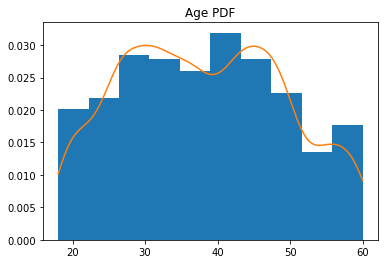

In [3]:
# 1. What is the probability distribution of age in the insurance dataset?

plt.hist(insurance["age"],density=True)
kde = KernelDensity(kernel="gaussian",bandwidth=2).fit(insurance["age"].dropna().to_numpy().reshape(-1,1))
age_range = np.linspace(insurance["age"].min(),insurance["age"].max(),1000)
pdf = np.exp(kde.score_samples(age_range.reshape(-1,1)))
plt.plot(age_range,pdf)
plt.title("Age PDF")
plt.show()

In [4]:
# 2. What is the probability of a patient having a BMI greater than 30?

patient_bmi_greater_than_30 = insurance[insurance["bmi"]>30].shape[0]
print("Probability of patient having a bmi greater than 30 is ",round(patient_bmi_greater_than_30/insurance.shape[0],2))

Probability of patient having a bmi greater than 30 is  0.52


<AxesSubplot:xlabel='claim', ylabel='Density'>

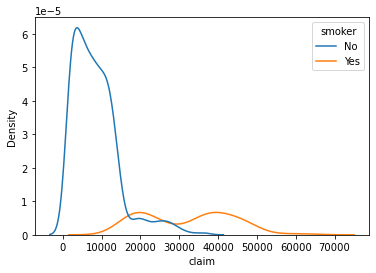

In [5]:
# 3. Plot distribution plot of claim for Smoker and non smoker. What changes you see in the plot?

sns.kdeplot(x=insurance["claim"],hue=insurance["smoker"])

- Claim for non-smoker is lesser than smokers.
- Most claim of non-smoker lie in range 0-15000 and Smoker's claim is greater than 15000.

<AxesSubplot:xlabel='age', ylabel='claim'>

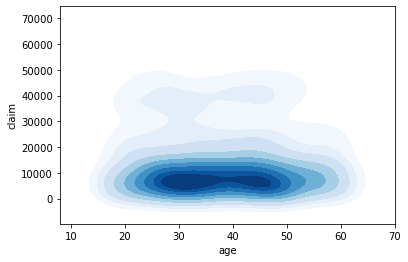

In [6]:
# 4. Plot the 2D probability density plot of claim and age in the insurance dataset?

sns.kdeplot(x=insurance["age"],y=insurance["claim"],cmap="Blues",fill=True,thresh=0.05)

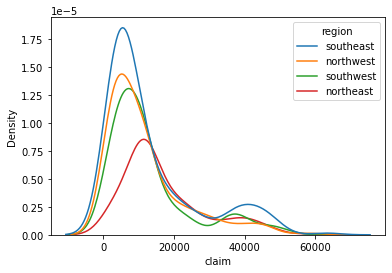

In [7]:
# 5. How does the disribution of claim changes for different region? Plot density plot and note down the observations

sns.kdeplot(x=insurance["claim"],hue=insurance["region"])
print("")
print("")

- Leaving northeast, all other regions have high density around same claim amount.
- All regions follow same trends of claims, global peak around 6000-10000 and a local peak around 4000

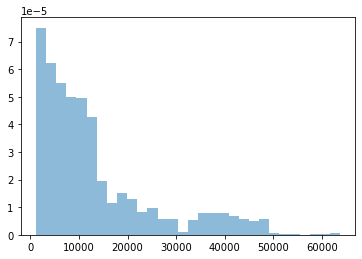

In [8]:
# 6. Plot PDF and CDF of claim in insurance data

# Approach1 - Histogram approach to which distribution follows
plt.hist(insurance["claim"],bins=30,density=True,alpha=0.5)
plt.show()

- As above hist plot is not normal we are going with non-parametric approach.

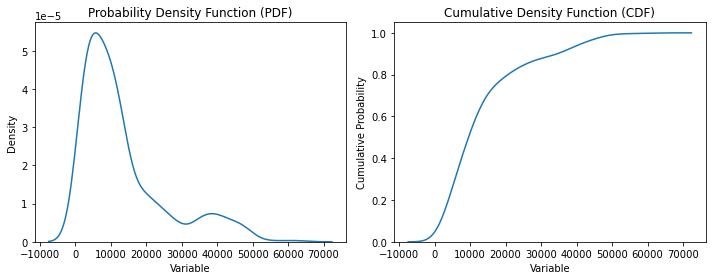

In [9]:
plt.figure(figsize=(10,4))

# plot pdf using KDE
plt.subplot(1,2,1)
sns.kdeplot(insurance["claim"])
plt.xlabel("Variable")
plt.ylabel("Density")
plt.title("Probability Density Function (PDF)")

# plot cdf using cumulative sum of KDE
plt.subplot(1,2,2)
sns.kdeplot(insurance["claim"],cumulative=True)
plt.xlabel("Variable")
plt.ylabel("Cumulative Probability")
plt.title("Cumulative Density Function (CDF)")

plt.tight_layout()
plt.show()

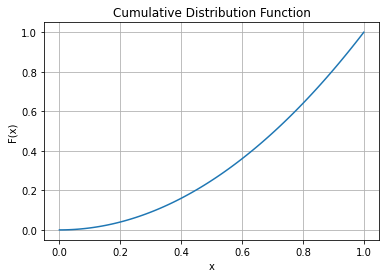

Probability that X is greater than 0.5 is  0.75


In [10]:
# 7. Given a probability density function f(x) = 2x for 0 <= x <= 1 and f(x) = 0 otherwise, compute the cumulative 
#distribution function F(x) and plot it. Use this to find the probability that X is greater than 0.5.

def pdf(x):
    if(0<=x<=1):
        return 2 * x
    else:
        return 0

def cdf(x):
    if(0<=x<= 1):
        return x ** 2
    else:
        return 1

x = np.linspace(0,1,100)
y_cdf = np.array([cdf(xi) for xi in x])
plt.plot(x,y_cdf)
plt.xlabel('x')
plt.ylabel('F(x)')
plt.title("Cumulative Distribution Function")
plt.grid(True)
plt.show()

print("Probability that X is greater than 0.5 is ",1 - cdf(0.5))

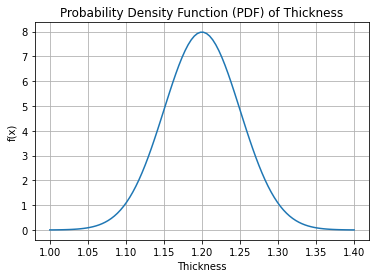

Probability that the thickness is between 1.1mm and 1.3mm is  0.95


In [11]:
# 8. In a manufacturing process, the thickness of a certain material is known to be normally distributed with a mean of 
# 1.2mm and a standard deviation of 0.05 mm. What is the probability density function of the thickness? Plot the PDF and 
# use it to compute the probability that the thickness is between 1.1 mm and 1.3 mm.

def pdf(x,mean,std_dev):
    return (1/(std_dev * np.sqrt(2 * np.pi)))*np.exp(-((x-mean)**2)/(2*std_dev**2))

mean = 1.2
std_dev = 0.05

x = np.linspace(1.0,1.4,100)
y_pdf = pdf(x,mean,std_dev)

plt.plot(x,y_pdf)
plt.xlabel("Thickness")
plt.ylabel("f(x)")
plt.title("Probability Density Function (PDF) of Thickness")
plt.grid(True)
plt.show()

print("Probability that the thickness is between 1.1mm and 1.3mm is ",round(integrate.quad(lambda x:pdf(x,mean,std_dev),1.1,1.3)[0],2))

In [12]:
# 9. A data scientist is investigating the distribution of customer ages in a retail store. She collects a sample of 100 
# ages and estimates the probability density function using kernel density estimation. What bandwidth should she choose to 
# obtain the best estimate?

ages = np.random.normal(loc=40,scale=10,size=100)
bandwidths = 10 ** np.linspace(-1,1,100)
params = {"bandwidth":bandwidths,"kernel":["gaussian"]}

grid = GridSearchCV(KernelDensity(),params,cv=5)
grid.fit(ages.reshape(-1,1))

best_bandwidth = grid.best_estimator_.bandwidth
print("Best Estimator : ",best_bandwidth)

Best Estimator :  4.5348785081285845
